# One-Class SVM on frozen DINOv3 ViT-L/16 embeddings


This notebook evaluates whether frozen DINOv3 ViT-L/16 image representations can support **clear-only anomaly detection** of culvert blockage using a One-Class Support Vector Machine (OCSVM).

A One-Class SVM is fitted using only images labelled **clear** from the development sites. Blocked images are not used to fit the anomaly detector or to select its final hyperparameters; they are introduced for performance evaluation after model selection.

The fixed cross-site split used across the dissertation is retained:

- **8 development sites** for model development and leave-one-site-out validation.
- **2 held-out test sites** reserved for final cross-site evaluation.

Three feature conditions are compared:

1. `raw` — untransformed DINOv3 CLS embeddings.
2. `development_standardised` — embeddings standardised using statistics fitted on the development data.
3. `site_calibrated` — embeddings adjusted using a small clear-image calibration sample from the evaluation site.

Hyperparameters are selected using clear-only nested leave-one-site-out validation. Final performance is reported using AUC, accuracy, precision, recall and F1 score on the two unseen sites.

> The notebook retains the executed experimental outputs that support the dissertation results.


In [ ]:
# Cell 1: Setup, paths, reproducibility and experiment settings

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------------
# Repository configuration
# ------------------------------------------------------------------
# Update PROJECT_ROOT.
PROJECT_ROOT = Path(".")

DATA_DIR = PROJECT_ROOT / "data"
EMBEDDING_DIR = DATA_DIR / "dinov3_vitl16_cls_embeddings"
SPLIT_PATH = DATA_DIR / "site_split.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "ocsvm_dinov3_vitl16"

# Existing variable names are retained below for compatibility with
# the original experimental code.
DINOV3_FOLDER = str(EMBEDDING_DIR)
OUTPUT_FOLDER = str(OUTPUT_DIR)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Calibration settings
CALIBRATION_SIZE = 20
FINAL_CALIBRATION_REPEATS = 10

# OCSVM hyperparameter grid
NU_GRID = [
    0.05,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5
]

GAMMA_GRID = [
    "scale",
    0.001,
    0.01,
    0.1
]

CONDITIONS = [
    "raw",
    "development_standardised",
    "site_calibrated"
]

print(f"Embedding directory: {DINOV3_FOLDER}")
print(f"Site split: {SPLIT_PATH}")
print(f"Output directory: {OUTPUT_FOLDER}")


In [ ]:
# Cell 2: Output saving helper

def save_output(obj, name, **kwargs):

    path = f"{OUTPUT_FOLDER}/{name}.csv"

    obj.to_csv(
        path,
        **kwargs
    )

    print(f"Saved: {name}.csv")

## 1. Load embeddings and fixed site split

Load the frozen DINOv3 CLS embeddings and their aligned metadata, then recover the predefined eight-development/two-test-site split. Keeping the site split fixed ensures that the comparison with other dissertation experiments uses the same spatial generalisation protocol.


In [ ]:
# Cell 3: Load frozen plain DINOv3 ViT-L/16 CLS embeddings and metadata

site_files = [
    "sites_corshamaqueduct_cam1",
    "Cornwall_BudeCedarGrove",
    "Devon_BarnstapleConeyGut_Scree",
    "Cornwall_Mevagissey_PreScree",
    "Cornwall_PenzanceCC",
    "Devon_Buckfastleigh",
    "sites_pilloutfall_cam1",
    "Cornwall_KingsandCP",
    "Devon_LympstoneScree",
    "sites_brutondam_cam1"
]

all_dino = []
all_meta = []

for site_file in site_files:

    all_dino.append(
        np.load(
            f"{DINOV3_FOLDER}/"
            f"dinov3_vitl16_cls_{site_file}.npy"
        )
    )

    all_meta.append(
        pd.read_csv(
            f"{DINOV3_FOLDER}/"
            f"meta_{site_file}.csv"
        )
    )

embeddings = np.vstack(
    all_dino
)

metadata = pd.concat(
    all_meta,
    ignore_index=True
)

assert len(embeddings) == len(metadata)
assert embeddings.shape == (4000, 1024)
assert {"site", "label"}.issubset(metadata.columns)
assert set(metadata["label"].unique()).issubset(
    {"clear", "blocked"}
)

ALL_SITES = sorted(
    metadata["site"].unique()
)

assert len(ALL_SITES) == 10

print(f"Loaded {embeddings.shape[0]} embeddings")
print(f"Embedding dimension: {embeddings.shape[1]}")
print(f"Number of sites: {len(ALL_SITES)}")

display(
    metadata
    .groupby(["site", "label"])
    .size()
    .unstack(fill_value=0)
)

Loaded 4000 embeddings
Embedding dimension: 1024
Number of sites: 10


label,blocked,clear
site,,
Cornwall_BudeCedarGrove,200,200
Cornwall_KingsandCP,200,200
Cornwall_Mevagissey_PreScree,200,200
Cornwall_PenzanceCC,200,200
Devon_BarnstapleConeyGut_Scree,200,200
Devon_Buckfastleigh,200,200
Devon_LympstoneScree,200,200
sites_brutondam_cam1,200,200
sites_corshamaqueduct_cam1,200,200


In [ ]:
# Cell 4: Load fixed development and held-out test site split

split_summary = pd.read_csv(
    SPLIT_PATH
)

DEVELOPMENT_SITES = (
    split_summary.loc[
        split_summary["role"] == "development",
        "site"
    ]
    .tolist()
)

TEST_SITES = (
    split_summary.loc[
        split_summary["role"] == "test",
        "site"
    ]
    .tolist()
)

assert len(DEVELOPMENT_SITES) == 8
assert len(TEST_SITES) == 2
assert set(DEVELOPMENT_SITES).isdisjoint(TEST_SITES)
assert set(split_summary["site"]) == set(ALL_SITES)

print("Development sites:")

for site in DEVELOPMENT_SITES:
    print(f"  {site}")

print("\nHeld-out test sites:")

for site in TEST_SITES:
    print(f"  {site}")

display(split_summary)

Development sites:
  Cornwall_KingsandCP
  Cornwall_Mevagissey_PreScree
  Cornwall_PenzanceCC
  Devon_BarnstapleConeyGut_Scree
  Devon_Buckfastleigh
  Devon_LympstoneScree
  sites_corshamaqueduct_cam1
  sites_pilloutfall_cam1

Held-out test sites:
  Cornwall_BudeCedarGrove
  sites_brutondam_cam1


,site,role
0,Cornwall_BudeCedarGrove,test
1,Cornwall_KingsandCP,development
2,Cornwall_Mevagissey_PreScree,development
3,Cornwall_PenzanceCC,development
4,Devon_BarnstapleConeyGut_Scree,development
5,Devon_Buckfastleigh,development
6,Devon_LympstoneScree,development
7,sites_brutondam_cam1,test
8,sites_corshamaqueduct_cam1,development
9,sites_pilloutfall_cam1,development


## 2. Data preparation helpers

The helper functions below retrieve observations by site and class and construct fold-specific training and evaluation arrays. Scaling and calibration are fitted within each fold to prevent information from the evaluation site leaking into model fitting.


In [ ]:
# Cell 5: Data access and transformation helpers

def indices_for_sites(
    selected_sites,
    label=None
):

    mask = metadata[
        "site"
    ].isin(
        selected_sites
    )

    if label is not None:

        mask &= metadata[
            "label"
        ].eq(
            label
        )

    return metadata.index[
        mask
    ].to_numpy()


def sample_clear_calibration_indices(
    site,
    calibration_size,
    seed
):

    clear_idx = indices_for_sites(
        [site],
        label="clear"
    )

    if len(clear_idx) <= calibration_size:

        raise ValueError(
            f"{site} has {len(clear_idx)} clear images. "
            f"Calibration size must be smaller than this count."
        )

    rng = np.random.default_rng(
        seed
    )

    return np.sort(
        rng.choice(
            clear_idx,
            size=calibration_size,
            replace=False
        )
    )


def make_fold_data(
    fit_sites,
    evaluation_sites,
    condition,
    calibration_size=CALIBRATION_SIZE,
    calibration_seed=RANDOM_SEED
):

    # Clear-only OCSVM training data
    fit_clear_idx = indices_for_sites(
        fit_sites,
        label="clear"
    )

    evaluation_idx = indices_for_sites(
        evaluation_sites
    )

    X_fit = embeddings[
        fit_clear_idx
    ].copy()

    X_eval = embeddings[
        evaluation_idx
    ].copy()

    y_eval_text = metadata.loc[
        evaluation_idx,
        "label"
    ].to_numpy()

    eval_site_names = metadata.loc[
        evaluation_idx,
        "site"
    ].to_numpy()

    calibration_rows = []


    # --------------------------------------------------------
    # Raw
    # --------------------------------------------------------

    if condition == "raw":

        pass


    # --------------------------------------------------------
    # Development-standardised
    # --------------------------------------------------------

    elif condition == "development_standardised":

        scaler = StandardScaler()

        X_fit = scaler.fit_transform(
            X_fit
        )

        X_eval = scaler.transform(
            X_eval
        )


    # --------------------------------------------------------
    # Site-calibrated
    # --------------------------------------------------------

    elif condition == "site_calibrated":

        centred_fit_parts = []

        # Centre each development site's clear embeddings
        for site in fit_sites:

            site_clear_idx = indices_for_sites(
                [site],
                label="clear"
            )

            site_mean = embeddings[
                site_clear_idx
            ].mean(axis=0)

            centred_fit_parts.append(
                embeddings[
                    site_clear_idx
                ]
                - site_mean
            )

        X_fit = np.vstack(
            centred_fit_parts
        )


        keep_mask = np.ones(
            len(evaluation_idx),
            dtype=bool
        )

        centred_eval = X_eval.copy()


        # Calibrate each evaluation site
        for site_number, site in enumerate(
            evaluation_sites
        ):

            site_seed = (
                calibration_seed
                + 1009 * site_number
            )

            calibration_idx = (
                sample_clear_calibration_indices(
                    site,
                    calibration_size,
                    site_seed
                )
            )

            site_reference = embeddings[
                calibration_idx
            ].mean(axis=0)

            site_position_mask = (
                eval_site_names == site
            )

            centred_eval[
                site_position_mask
            ] = (
                centred_eval[
                    site_position_mask
                ]
                - site_reference
            )

            calibration_position_mask = np.isin(
                evaluation_idx,
                calibration_idx
            )

            keep_mask &= (
                ~calibration_position_mask
            )

            calibration_rows.extend([
                {
                    "site": site,
                    "metadata_index": int(idx),
                    "calibration_seed": calibration_seed
                }
                for idx in calibration_idx
            ])


        X_eval = centred_eval[
            keep_mask
        ]

        evaluation_idx = evaluation_idx[
            keep_mask
        ]

        y_eval_text = y_eval_text[
            keep_mask
        ]

        eval_site_names = eval_site_names[
            keep_mask
        ]


    else:

        raise ValueError(
            f"Unknown condition: {condition}"
        )


    y_eval = (
        y_eval_text == "blocked"
    ).astype(int)


    return {
        "X_fit": X_fit,
        "X_eval": X_eval,
        "y_eval": y_eval,
        "evaluation_idx": evaluation_idx,
        "evaluation_sites": eval_site_names,
        "calibration_rows": pd.DataFrame(
            calibration_rows
        )
    }

## 3. Default OCSVM reference

Evaluate the default `OneClassSVM()` configuration first. This provides a reference point before clear-only hyperparameter selection and allows the effect of each feature treatment to be assessed independently of tuning.


In [ ]:
# Cell 6: Default OCSVM baseline on raw embeddings

default_rows = []
default_prediction_parts = []


for validation_site in DEVELOPMENT_SITES:

    fit_sites = [
        site
        for site in DEVELOPMENT_SITES
        if site != validation_site
    ]

    fold = make_fold_data(
        fit_sites=fit_sites,
        evaluation_sites=[validation_site],
        condition="raw"
    )

    model = OneClassSVM()

    model.fit(
        fold["X_fit"]
    )

    scores = (
        -model
        .decision_function(
            fold["X_eval"]
        )
        .ravel()
    )

    predictions = (
        model.predict(
            fold["X_eval"]
        ) == -1
    ).astype(int)


    default_prediction_parts.append(
        pd.DataFrame({
            "validation_site": validation_site,
            "metadata_index": fold["evaluation_idx"],
            "true_label": fold["y_eval"],
            "anomaly_score": scores,
            "prediction": predictions
        })
    )


    default_rows.append({
        "validation_site": validation_site,

        "auc": roc_auc_score(
            fold["y_eval"],
            scores
        ),

        "precision": precision_score(
            fold["y_eval"],
            predictions,
            zero_division=0
        ),

        "recall": recall_score(
            fold["y_eval"],
            predictions,
            zero_division=0
        ),

        "f1": f1_score(
            fold["y_eval"],
            predictions,
            zero_division=0
        )
    })


default_predictions = pd.concat(
    default_prediction_parts,
    ignore_index=True
)

default_per_site = pd.DataFrame(
    default_rows
)


default_summary = pd.Series({

    "auc": roc_auc_score(
        default_predictions["true_label"],
        default_predictions["anomaly_score"]
    ),

    "precision": precision_score(
        default_predictions["true_label"],
        default_predictions["prediction"],
        zero_division=0
    ),

    "recall": recall_score(
        default_predictions["true_label"],
        default_predictions["prediction"],
        zero_division=0
    ),

    "f1": f1_score(
        default_predictions["true_label"],
        default_predictions["prediction"],
        zero_division=0
    )
})


print(
    "Default hyperparameters, pooled across 8 development sites"
)

display(
    default_summary
)

display(
    default_per_site
)

Default hyperparameters, pooled across 8 development sites


,0
auc,0.615297
precision,0.511494
recall,0.945625
f1,0.663888


,validation_site,auc,precision,recall,f1
0,Cornwall_KingsandCP,0.854150,0.501253,1.000,0.667780
1,Cornwall_Mevagissey_PreScree,0.695925,0.503778,1.000,0.670017
2,Cornwall_PenzanceCC,0.774900,0.501253,1.000,0.667780
3,Devon_BarnstapleConeyGut_Scree,0.757100,0.644444,0.870,0.740426
4,Devon_Buckfastleigh,0.337400,0.482850,0.915,0.632124
5,Devon_LympstoneScree,0.419325,0.482249,0.815,0.605948
6,sites_corshamaqueduct_cam1,0.773250,0.511509,1.000,0.676819
7,sites_pilloutfall_cam1,0.521975,0.501299,0.965,0.659829


In [ ]:
# Cell 7: Save default baseline outputs

save_output(
    default_summary,
    "default_summary",
    header=["value"]
)

save_output(
    default_per_site,
    "default_per_site",
    index=False
)

Saved: default_summary.csv
Saved: default_per_site.csv


In [ ]:
# Cell 8: Default OCSVM under standardisation and site calibration

default_extra_rows = []
default_extra_prediction_parts = []


for condition in [
    "development_standardised",
    "site_calibrated"
]:

    for validation_site in DEVELOPMENT_SITES:

        fit_sites = [
            site
            for site in DEVELOPMENT_SITES
            if site != validation_site
        ]

        fold = make_fold_data(
            fit_sites=fit_sites,
            evaluation_sites=[validation_site],
            condition=condition
        )

        model = OneClassSVM()

        model.fit(
            fold["X_fit"]
        )

        scores = (
            -model
            .decision_function(
                fold["X_eval"]
            )
            .ravel()
        )

        predictions = (
            model.predict(
                fold["X_eval"]
            ) == -1
        ).astype(int)


        default_extra_prediction_parts.append(
            pd.DataFrame({
                "condition": condition,
                "validation_site": validation_site,
                "metadata_index": fold["evaluation_idx"],
                "true_label": fold["y_eval"],
                "anomaly_score": scores,
                "prediction": predictions
            })
        )


        default_extra_rows.append({

            "condition": condition,
            "validation_site": validation_site,

            "auc": roc_auc_score(
                fold["y_eval"],
                scores
            ),

            "precision": precision_score(
                fold["y_eval"],
                predictions,
                zero_division=0
            ),

            "recall": recall_score(
                fold["y_eval"],
                predictions,
                zero_division=0
            ),

            "f1": f1_score(
                fold["y_eval"],
                predictions,
                zero_division=0
            )
        })


default_extra_predictions = pd.concat(
    default_extra_prediction_parts,
    ignore_index=True
)

default_extra_per_site = pd.DataFrame(
    default_extra_rows
)


def pooled_default_metrics(group):

    return pd.Series({

        "auc": roc_auc_score(
            group["true_label"],
            group["anomaly_score"]
        ),

        "precision": precision_score(
            group["true_label"],
            group["prediction"],
            zero_division=0
        ),

        "recall": recall_score(
            group["true_label"],
            group["prediction"],
            zero_division=0
        ),

        "f1": f1_score(
            group["true_label"],
            group["prediction"],
            zero_division=0
        )
    })


default_extra_pooled_summary = (
    default_extra_predictions
    .groupby("condition")
    .apply(pooled_default_metrics)
)

display(
    default_extra_per_site
)

display(
    default_extra_pooled_summary
)

,condition,validation_site,auc,precision,recall,f1
0,development_standardised,Cornwall_KingsandCP,0.858550,0.500000,1.000,0.666667
1,development_standardised,Cornwall_Mevagissey_PreScree,0.689200,0.500000,1.000,0.666667
2,development_standardised,Cornwall_PenzanceCC,0.778725,0.500000,1.000,0.666667
3,development_standardised,Devon_BarnstapleConeyGut_Scree,0.760775,0.519481,1.000,0.683761
4,development_standardised,Devon_Buckfastleigh,0.369825,0.500000,1.000,0.666667
5,development_standardised,Devon_LympstoneScree,0.447075,0.496183,0.975,0.657673
6,development_standardised,sites_corshamaqueduct_cam1,0.771150,0.500000,1.000,0.666667
7,development_standardised,sites_pilloutfall_cam1,0.529575,0.500000,1.000,0.666667
8,site_calibrated,Cornwall_KingsandCP,0.898806,0.740458,0.970,0.839827
9,site_calibrated,Cornwall_Mevagissey_PreScree,0.913056,0.643087,1.000,0.782779


,auc,precision,recall,f1
condition,,,,
development_standardised,0.615538,0.501888,0.996875,0.667643
site_calibrated,0.805279,0.646399,0.936875,0.764991


In [ ]:
# Cell 9: Default hyperparameters, two unseen test sites

# Uses the same calibration seeds as the tuned evaluation, so the same
# held-out calibration draws are used in both. Hyperparameters are the only
# thing that differs between this cell and the tuned evaluation.

default_test_prediction_parts = []

for condition in CONDITIONS:

    if condition == "site_calibrated":

        calibration_seeds = [
            RANDOM_SEED + 300000 + repeat
            for repeat in range(FINAL_CALIBRATION_REPEATS)
        ]

    else:

        calibration_seeds = [
            RANDOM_SEED + 300000
        ]


    for calibration_seed in calibration_seeds:

        fold = make_fold_data(
            fit_sites=DEVELOPMENT_SITES,
            evaluation_sites=TEST_SITES,
            condition=condition,
            calibration_seed=calibration_seed
        )

        model = OneClassSVM()

        model.fit(
            fold["X_fit"]
        )

        scores = (
            -model
            .decision_function(
                fold["X_eval"]
            )
            .ravel()
        )

        predictions = (
            model.predict(
                fold["X_eval"]
            ) == -1
        ).astype(int)


        default_test_prediction_parts.append(
            pd.DataFrame({
                "condition": condition,
                "calibration_seed": calibration_seed,
                "site": fold["evaluation_sites"],
                "metadata_index": fold["evaluation_idx"],
                "true_label": fold["y_eval"],
                "anomaly_score": scores,
                "prediction": predictions
            })
        )


default_test_predictions = pd.concat(
    default_test_prediction_parts,
    ignore_index=True
)


print(
    "Default hyperparameters, two unseen test sites"
)

display(
    default_test_predictions
    .groupby("condition")[
        ["true_label", "prediction"]
    ]
    .apply(
        lambda g: pd.Series({
            "n": len(g),
            "predicted_blocked_rate":
                g["prediction"].mean()
        })
    )
)

Default hyperparameters, two unseen test sites


,n,predicted_blocked_rate
condition,,
development_standardised,800.0,0.920000
raw,800.0,0.668750
site_calibrated,7600.0,0.630658


In [ ]:
# Cell 10: Aggregate default test performance

def default_test_metric_row(group):

    y_true = (
        group["true_label"]
        .to_numpy()
    )

    scores = (
        group["anomaly_score"]
        .to_numpy()
    )

    predictions = (
        group["prediction"]
        .to_numpy()
    )

    return pd.Series({
        "auc": roc_auc_score(
            y_true,
            scores
        ),

        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0
        )
    })


default_test_repeat_metrics = (
    default_test_predictions
    .groupby([
        "condition",
        "calibration_seed"
    ])
    .apply(
        default_test_metric_row
    )
    .reset_index()
)


default_test_overall_summary = (
    default_test_repeat_metrics
    .groupby("condition")
    .agg(
        mean_auc=("auc", "mean"),
        std_auc=("auc", "std"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        std_recall=("recall", "std"),
        mean_f1=("f1", "mean"),
        std_f1=("f1", "std"),
        n_repeats=("calibration_seed", "nunique")
    )
    .reset_index()
)


display(
    default_test_overall_summary
)

,condition,mean_auc,std_auc,mean_precision,mean_recall,std_recall,mean_f1,std_f1,n_repeats
0,development_standardised,0.541650,NaN,0.506793,0.93250,NaN,0.656690,NaN,1
1,raw,0.554669,NaN,0.536449,0.71750,NaN,0.613904,NaN,1
2,site_calibrated,0.787440,0.008884,0.664119,0.79575,0.019545,0.723915,0.010846,10


In [ ]:
# Cell 11: Save default test outputs

save_output(
    default_test_predictions,
    "default_test_predictions",
    index=False
)

save_output(
    default_test_overall_summary,
    "default_test_overall_summary",
    index=False
)

Saved: default_test_predictions.csv
Saved: default_test_overall_summary.csv


## 4. Clear-only hyperparameter selection

The OCSVM hyperparameters $\nu$ and $\gamma$ are selected without using blocked examples as training signal. Candidate settings are assessed by how consistently they retain clear observations across unseen development sites.

Nested leave-one-site-out validation separates hyperparameter selection from the outer development-site evaluation, reducing optimistic model-selection bias.


In [ ]:
# Cell 12: Clear-only OCSVM hyperparameter selection helper

def evaluate_hyperparameter_grid(
    candidate_sites,
    condition,
    seed_offset=0
):

    rows = []

    for nu in NU_GRID:

        for gamma in GAMMA_GRID:

            site_acceptance_rates = []


            for fold_number, validation_site in enumerate(
                candidate_sites
            ):

                fit_sites = [
                    site
                    for site in candidate_sites
                    if site != validation_site
                ]


                # ------------------------------------------------
                # Clear-only training data
                # ------------------------------------------------

                fit_clear_idx = indices_for_sites(
                    fit_sites,
                    label="clear"
                )

                X_fit = embeddings[
                    fit_clear_idx
                ].copy()


                # ------------------------------------------------
                # Clear-only held-out validation data
                # ------------------------------------------------

                validation_clear_idx = indices_for_sites(
                    [validation_site],
                    label="clear"
                )

                X_validation = embeddings[
                    validation_clear_idx
                ].copy()


                # ------------------------------------------------
                # Raw embeddings
                # ------------------------------------------------

                if condition == "raw":

                    pass


                # ------------------------------------------------
                # Development standardisation
                # ------------------------------------------------

                elif condition == "development_standardised":

                    scaler = StandardScaler()

                    X_fit = scaler.fit_transform(
                        X_fit
                    )

                    X_validation = scaler.transform(
                        X_validation
                    )


                # ------------------------------------------------
                # Site calibration
                # ------------------------------------------------

                elif condition == "site_calibrated":

                    centred_fit_parts = []


                    # Centre each development site using
                    # its own clear-image mean
                    for site in fit_sites:

                        site_clear_idx = indices_for_sites(
                            [site],
                            label="clear"
                        )

                        site_mean = embeddings[
                            site_clear_idx
                        ].mean(axis=0)

                        centred_fit_parts.append(
                            embeddings[
                                site_clear_idx
                            ]
                            - site_mean
                        )


                    X_fit = np.vstack(
                        centred_fit_parts
                    )


                    # Use clear reference images from the
                    # held-out validation site for calibration
                    calibration_indices = (
                        sample_clear_calibration_indices(
                            validation_site,
                            CALIBRATION_SIZE,
                            RANDOM_SEED
                            + seed_offset
                            + fold_number
                        )
                    )


                    reference_mean = embeddings[
                        calibration_indices
                    ].mean(axis=0)


                    # Do not evaluate on the calibration images
                    evaluation_indices = np.setdiff1d(
                        validation_clear_idx,
                        calibration_indices
                    )


                    X_validation = (
                        embeddings[
                            evaluation_indices
                        ]
                        - reference_mean
                    )


                else:

                    raise ValueError(
                        f"Unknown condition: {condition}"
                    )


                # ------------------------------------------------
                # Fit One-Class SVM using clear images only
                # ------------------------------------------------

                model = OneClassSVM(
                    kernel="rbf",
                    nu=nu,
                    gamma=gamma
                )

                model.fit(
                    X_fit
                )


                # ------------------------------------------------
                # Native OCSVM decision
                #
                # +1 = inlier / clear
                # -1 = outlier / anomaly
                # ------------------------------------------------

                predictions = model.predict(
                    X_validation
                )


                # How many unseen clear images are correctly
                # accepted as normal?
                clear_acceptance_rate = np.mean(
                    predictions == 1
                )


                site_acceptance_rates.append(
                    clear_acceptance_rate
                )


            # ----------------------------------------------------
            # Aggregate across held-out development sites
            # ----------------------------------------------------

            rows.append({

                "nu": nu,
                "gamma": gamma,

                "mean_clear_acceptance":
                    float(
                        np.mean(
                            site_acceptance_rates
                        )
                    ),

                "std_clear_acceptance":
                    float(
                        np.std(
                            site_acceptance_rates
                        )
                    ),

                "minimum_clear_acceptance":
                    float(
                        np.min(
                            site_acceptance_rates
                        )
                    )
            })


    return (
        pd.DataFrame(
            rows
        )
        .sort_values(
            by=[
                "mean_clear_acceptance",
                "minimum_clear_acceptance",
                "std_clear_acceptance"
            ],
            ascending=[
                False,
                False,
                True
            ]
        )
        .reset_index(
            drop=True
        )
    )

In [ ]:
# Cell 13: Nested leave-one-site-out clear-only hyperparameter selection

nested_selection_tables = {}
nested_selection_rows = []


for condition in CONDITIONS:

    print(
        f"Running clear-only nested selection: {condition}"
    )


    condition_rows = []


    for outer_number, validation_site in enumerate(
        DEVELOPMENT_SITES
    ):

        inner_sites = [
            site
            for site in DEVELOPMENT_SITES
            if site != validation_site
        ]


        # ----------------------------------------------------
        # Select nu and gamma using CLEAR images only
        # from the inner development sites
        # ----------------------------------------------------

        inner_results = evaluate_hyperparameter_grid(
            candidate_sites=inner_sites,
            condition=condition,
            seed_offset=(
                10000 * outer_number
            )
        )


        best = inner_results.iloc[0]


        selected_nu = float(
            best["nu"]
        )

        selected_gamma = best[
            "gamma"
        ]


        # ----------------------------------------------------
        # Evaluate selected configuration on CLEAR images
        # from the held-out outer development site
        # ----------------------------------------------------

        fit_sites = inner_sites


        fit_clear_idx = indices_for_sites(
            fit_sites,
            label="clear"
        )

        X_fit = embeddings[
            fit_clear_idx
        ].copy()


        validation_clear_idx = indices_for_sites(
            [validation_site],
            label="clear"
        )

        X_validation = embeddings[
            validation_clear_idx
        ].copy()


        # ----------------------------------------------------
        # Apply preprocessing condition
        # ----------------------------------------------------

        if condition == "raw":

            pass


        elif condition == "development_standardised":

            scaler = StandardScaler()

            X_fit = scaler.fit_transform(
                X_fit
            )

            X_validation = scaler.transform(
                X_validation
            )


        elif condition == "site_calibrated":

            centred_fit_parts = []


            for site in fit_sites:

                site_clear_idx = indices_for_sites(
                    [site],
                    label="clear"
                )

                site_mean = embeddings[
                    site_clear_idx
                ].mean(axis=0)

                centred_fit_parts.append(
                    embeddings[
                        site_clear_idx
                    ]
                    - site_mean
                )


            X_fit = np.vstack(
                centred_fit_parts
            )


            calibration_indices = (
                sample_clear_calibration_indices(
                    validation_site,
                    CALIBRATION_SIZE,
                    RANDOM_SEED
                    + 100000
                    + outer_number
                )
            )


            reference_mean = embeddings[
                calibration_indices
            ].mean(axis=0)


            evaluation_indices = np.setdiff1d(
                validation_clear_idx,
                calibration_indices
            )


            X_validation = (
                embeddings[
                    evaluation_indices
                ]
                - reference_mean
            )


        else:

            raise ValueError(
                f"Unknown condition: {condition}"
            )


        # ----------------------------------------------------
        # Fit OCSVM using clear images only
        # ----------------------------------------------------

        model = OneClassSVM(
            kernel="rbf",
            nu=selected_nu,
            gamma=selected_gamma
        )

        model.fit(
            X_fit
        )


        predictions = model.predict(
            X_validation
        )


        clear_acceptance = np.mean(
            predictions == 1
        )


        condition_rows.append({

            "condition":
                condition,

            "validation_site":
                validation_site,

            "selected_nu":
                selected_nu,

            "selected_gamma":
                str(
                    selected_gamma
                ),

            "clear_acceptance":
                float(
                    clear_acceptance
                )
        })


    condition_table = pd.DataFrame(
        condition_rows
    )


    nested_selection_tables[
        condition
    ] = condition_table


    nested_selection_rows.append({

        "condition":
            condition,

        "mean_clear_acceptance":
            condition_table[
                "clear_acceptance"
            ].mean(),

        "std_clear_acceptance":
            condition_table[
                "clear_acceptance"
            ].std(),

        "minimum_clear_acceptance":
            condition_table[
                "clear_acceptance"
            ].min()
    })


nested_clear_summary = pd.DataFrame(
    nested_selection_rows
)


display(
    nested_clear_summary
)

Running clear-only nested selection: raw
Running clear-only nested selection: development_standardised
Running clear-only nested selection: site_calibrated


,condition,mean_clear_acceptance,std_clear_acceptance,minimum_clear_acceptance
0,raw,0.686875,0.215140,0.335000
1,development_standardised,0.146875,0.181913,0.000000
2,site_calibrated,0.879167,0.259353,0.238889


In [ ]:
# Cell 14: Save clear-only nested validation results

import pickle

clear_only_checkpoint = {
    "nested_selection_tables": nested_selection_tables,
    "nested_clear_summary": nested_clear_summary
}

with open(
    f"{OUTPUT_FOLDER}/clear_only_nested_validation_checkpoint.pkl",
    "wb"
) as f:

    pickle.dump(
        clear_only_checkpoint,
        f
    )


save_output(
    nested_clear_summary,
    "nested_clear_summary",
    index=False
)


for condition, table in nested_selection_tables.items():

    save_output(
        table,
        f"nested_clear_selection_{condition}",
        index=False
    )


print(
    "Saved clear-only nested validation outputs."
)

Saved: nested_clear_summary.csv
Saved: nested_clear_selection_raw.csv
Saved: nested_clear_selection_development_standardised.csv
Saved: nested_clear_selection_site_calibrated.csv
Saved clear-only nested validation outputs.


In [ ]:
# Cell 15: Inspect clear-only hyperparameter selections across nested folds

selection_rows = []

for condition in CONDITIONS:

    table = nested_selection_tables[
        condition
    ]

    print(
        f"\nSelected hyperparameters: {condition}"
    )

    display(
        table
    )


    # Count how often each nu/gamma combination was selected
    counts = (
        table
        .groupby(
            [
                "selected_nu",
                "selected_gamma"
            ]
        )
        .size()
        .reset_index(
            name="times_selected"
        )
        .sort_values(
            "times_selected",
            ascending=False
        )
    )

    counts.insert(
        0,
        "condition",
        condition
    )

    selection_rows.append(
        counts
    )


nested_hyperparameter_counts = pd.concat(
    selection_rows,
    ignore_index=True
)


print(
    "\nHyperparameter selection frequency:"
)

display(
    nested_hyperparameter_counts
)


save_output(
    nested_hyperparameter_counts,
    "nested_clear_hyperparameter_selection_frequency",
    index=False
)


Selected hyperparameters: raw


,condition,validation_site,selected_nu,selected_gamma,clear_acceptance
0,raw,Cornwall_KingsandCP,0.05,0.001,0.800
1,raw,Cornwall_Mevagissey_PreScree,0.05,0.001,0.335
2,raw,Cornwall_PenzanceCC,0.05,0.001,0.560
3,raw,Devon_BarnstapleConeyGut_Scree,0.05,0.001,0.935
4,raw,Devon_Buckfastleigh,0.05,0.001,0.830
5,raw,Devon_LympstoneScree,0.05,0.001,0.900
6,raw,sites_corshamaqueduct_cam1,0.05,0.001,0.480
7,raw,sites_pilloutfall_cam1,0.05,0.001,0.655



Selected hyperparameters: development_standardised


,condition,validation_site,selected_nu,selected_gamma,clear_acceptance
0,development_standardised,Cornwall_KingsandCP,0.05,scale,0.015
1,development_standardised,Cornwall_Mevagissey_PreScree,0.05,scale,0.050
2,development_standardised,Cornwall_PenzanceCC,0.05,scale,0.000
3,development_standardised,Devon_BarnstapleConeyGut_Scree,0.05,scale,0.535
4,development_standardised,Devon_Buckfastleigh,0.05,scale,0.115
5,development_standardised,Devon_LympstoneScree,0.05,scale,0.285
6,development_standardised,sites_corshamaqueduct_cam1,0.05,scale,0.035
7,development_standardised,sites_pilloutfall_cam1,0.05,scale,0.140



Selected hyperparameters: site_calibrated


,condition,validation_site,selected_nu,selected_gamma,clear_acceptance
0,site_calibrated,Cornwall_KingsandCP,0.05,0.001,0.966667
1,site_calibrated,Cornwall_Mevagissey_PreScree,0.05,0.001,0.933333
2,site_calibrated,Cornwall_PenzanceCC,0.05,0.001,0.972222
3,site_calibrated,Devon_BarnstapleConeyGut_Scree,0.05,0.001,0.966667
4,site_calibrated,Devon_Buckfastleigh,0.05,0.001,0.994444
5,site_calibrated,Devon_LympstoneScree,0.05,0.001,0.988889
6,site_calibrated,sites_corshamaqueduct_cam1,0.05,0.001,0.238889
7,site_calibrated,sites_pilloutfall_cam1,0.05,0.001,0.972222



Hyperparameter selection frequency:


,condition,selected_nu,selected_gamma,times_selected
0,raw,0.05,0.001,8
1,development_standardised,0.05,scale,8
2,site_calibrated,0.05,0.001,8


Saved: nested_clear_hyperparameter_selection_frequency.csv


## 5. Select the final configuration

After examining stability across the nested development folds, the full set of development sites is used to select one final OCSVM configuration for each feature condition. These parameters are then frozen before held-out testing.


In [ ]:
# Cell 16: Select final OCSVM hyperparameters using clear images only

final_tuning_tables = {}
final_parameters = {}

for condition in CONDITIONS:

    print(
        f"Final clear-only tuning: {condition}"
    )

    tuning_table = evaluate_hyperparameter_grid(
        candidate_sites=DEVELOPMENT_SITES,
        condition=condition,
        seed_offset=200000
    )

    final_tuning_tables[
        condition
    ] = tuning_table

    best = tuning_table.iloc[0]

    final_parameters[
        condition
    ] = {
        "nu": float(
            best["nu"]
        ),
        "gamma": best["gamma"]
    }


final_parameter_summary = pd.DataFrame([
    {
        "condition": condition,

        "nu": values["nu"],

        "gamma": str(
            values["gamma"]
        ),

        "mean_clear_acceptance":
            final_tuning_tables[
                condition
            ].iloc[0][
                "mean_clear_acceptance"
            ],

        "minimum_clear_acceptance":
            final_tuning_tables[
                condition
            ].iloc[0][
                "minimum_clear_acceptance"
            ],

        "std_clear_acceptance":
            final_tuning_tables[
                condition
            ].iloc[0][
                "std_clear_acceptance"
            ]
    }

    for condition, values
    in final_parameters.items()
])


display(
    final_parameter_summary
)

Final clear-only tuning: raw
Final clear-only tuning: development_standardised
Final clear-only tuning: site_calibrated


,condition,nu,gamma,mean_clear_acceptance,minimum_clear_acceptance,std_clear_acceptance
0,raw,0.05,0.001,0.686875,0.335000,0.201245
1,development_standardised,0.05,scale,0.146875,0.000000,0.170164
2,site_calibrated,0.05,0.001,0.889583,0.305556,0.221325


In [ ]:
# Cell 17: Inspect full clear-only hyperparameter rankings

for condition in CONDITIONS:

    print(
        f"\nFull clear-only ranking: {condition}"
    )

    display(
        final_tuning_tables[
            condition
        ]
    )


Full clear-only ranking: raw


,nu,gamma,mean_clear_acceptance,std_clear_acceptance,minimum_clear_acceptance
0,0.05,0.001,0.686875,0.201245,0.335
1,0.10,0.001,0.575625,0.229475,0.250
2,0.05,scale,0.498750,0.218557,0.215
3,0.20,0.001,0.397500,0.225873,0.160
4,0.10,scale,0.396250,0.224691,0.160
5,0.30,0.001,0.285625,0.218767,0.115
6,0.20,scale,0.245625,0.217104,0.080
7,0.05,0.01,0.225625,0.210586,0.060
8,0.40,0.001,0.204375,0.211075,0.055
9,0.30,scale,0.175000,0.211645,0.020



Full clear-only ranking: development_standardised


,nu,gamma,mean_clear_acceptance,std_clear_acceptance,minimum_clear_acceptance
0,0.05,scale,0.146875,0.170164,0.0
1,0.05,0.001,0.138750,0.162206,0.0
2,0.10,scale,0.110000,0.137976,0.0
3,0.10,0.001,0.106250,0.135456,0.0
4,0.20,scale,0.058125,0.081583,0.0
5,0.20,0.001,0.051875,0.072022,0.0
6,0.30,scale,0.030000,0.053033,0.0
7,0.30,0.001,0.028125,0.051596,0.0
8,0.40,scale,0.017500,0.037749,0.0
9,0.40,0.001,0.016875,0.036137,0.0



Full clear-only ranking: site_calibrated


,nu,gamma,mean_clear_acceptance,std_clear_acceptance,minimum_clear_acceptance
0,0.05,0.001,0.889583,0.221325,0.305556
1,0.05,0.01,0.862500,0.230166,0.255556
2,0.10,0.001,0.847917,0.264530,0.150000
3,0.10,0.01,0.828472,0.270579,0.116667
4,0.05,scale,0.797222,0.269902,0.088889
5,0.10,scale,0.775694,0.264341,0.083333
6,0.20,0.001,0.775694,0.273409,0.061111
7,0.20,0.01,0.751389,0.264090,0.061111
8,0.20,scale,0.704861,0.264377,0.022222
9,0.30,0.001,0.679861,0.263917,0.005556


In [ ]:
# Cell 18: Save final clear-only hyperparameter tuning outputs

# Save final selected hyperparameters
save_output(
    final_parameter_summary,
    "final_clear_only_parameters",
    index=False
)


# Save full tuning tables for each condition
for condition, table in final_tuning_tables.items():

    save_output(
        table,
        f"final_clear_only_tuning_{condition}",
        index=False
    )


print("\nFinal clear-only OCSVM parameters:")

display(
    final_parameter_summary
)

print(
    "\nFinal hyperparameter tuning outputs saved."
)

Saved: final_clear_only_parameters.csv
Saved: final_clear_only_tuning_raw.csv
Saved: final_clear_only_tuning_development_standardised.csv
Saved: final_clear_only_tuning_site_calibrated.csv

Final clear-only OCSVM parameters:


,condition,nu,gamma,mean_clear_acceptance,minimum_clear_acceptance,std_clear_acceptance
0,raw,0.05,0.001,0.686875,0.335000,0.201245
1,development_standardised,0.05,scale,0.146875,0.000000,0.170164
2,site_calibrated,0.05,0.001,0.889583,0.305556,0.221325



Final hyperparameter tuning outputs saved.


## 6. Development-site evaluation

The selected clear-only configurations are evaluated across the development sites. At this stage blocked labels are used **only to calculate performance metrics**, not to fit the OCSVM or choose its hyperparameters.


In [ ]:
# Cell 19: Evaluate final clear-only OCSVM configuration on development sites
# Blocked labels are used here for EVALUATION ONLY

development_evaluation_rows = []


for condition in CONDITIONS:

    print(
        f"Development evaluation: {condition}"
    )

    parameters = final_parameters[
        condition
    ]


    for fold_number, validation_site in enumerate(
        DEVELOPMENT_SITES
    ):

        fit_sites = [
            site
            for site in DEVELOPMENT_SITES
            if site != validation_site
        ]


        # ----------------------------------------------------
        # Prepare fold
        #
        # X_fit remains CLEAR ONLY.
        # X_eval contains clear + blocked images for evaluation.
        # ----------------------------------------------------

        fold = make_fold_data(
            fit_sites=fit_sites,
            evaluation_sites=[
                validation_site
            ],
            condition=condition,
            calibration_seed=(
                RANDOM_SEED
                + 400000
                + fold_number
            )
        )


        # ----------------------------------------------------
        # Fit OCSVM using clear images only
        # ----------------------------------------------------

        model = OneClassSVM(
            kernel="rbf",
            nu=parameters["nu"],
            gamma=parameters["gamma"]
        )

        model.fit(
            fold["X_fit"]
        )


        # ----------------------------------------------------
        # Continuous anomaly score
        #
        # Larger score = more anomalous
        # Used for ROC-AUC only
        # ----------------------------------------------------

        anomaly_scores = (
            -model
            .decision_function(
                fold["X_eval"]
            )
            .ravel()
        )


        # ----------------------------------------------------
        # Native OCSVM classification
        #
        # model.predict:
        # +1 = inlier  -> clear
        # -1 = outlier -> blocked/anomaly
        #
        # Convert to:
        # 0 = clear
        # 1 = blocked
        # ----------------------------------------------------

        native_predictions = (
            model.predict(
                fold["X_eval"]
            ) == -1
        ).astype(int)


        y_true = fold[
            "y_eval"
        ]


        # ----------------------------------------------------
        # Evaluation metrics
        # ----------------------------------------------------

        development_evaluation_rows.append({

            "condition":
                condition,

            "validation_site":
                validation_site,

            "nu":
                parameters["nu"],

            "gamma":
                str(
                    parameters["gamma"]
                ),

            "auc":
                roc_auc_score(
                    y_true,
                    anomaly_scores
                ),

            "accuracy":
                accuracy_score(
                    y_true,
                    native_predictions
                ),

            "precision":
                precision_score(
                    y_true,
                    native_predictions,
                    zero_division=0
                ),

            "recall":
                recall_score(
                    y_true,
                    native_predictions,
                    zero_division=0
                ),

            "f1":
                f1_score(
                    y_true,
                    native_predictions,
                    zero_division=0
                ),

            "predicted_blocked_rate":
                float(
                    native_predictions.mean()
                )
        })


development_evaluation_df = pd.DataFrame(
    development_evaluation_rows
)


# ------------------------------------------------------------
# Summary across development sites
# ------------------------------------------------------------

development_evaluation_summary = (
    development_evaluation_df
    .groupby(
        "condition"
    )[
        [
            "auc",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "predicted_blocked_rate"
        ]
    ]
    .agg([
        "mean",
        "std"
    ])
)


display(
    development_evaluation_df
)

display(
    development_evaluation_summary
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

save_output(
    development_evaluation_df,
    "development_clear_only_ocsVM_evaluation",
    index=False
)

save_output(
    development_evaluation_summary,
    "development_clear_only_ocsVM_evaluation_summary"
)

Development evaluation: raw
Development evaluation: development_standardised
Development evaluation: site_calibrated


,condition,validation_site,nu,gamma,auc,accuracy,precision,recall,f1,predicted_blocked_rate
0,raw,Cornwall_KingsandCP,0.05,0.001,0.850700,0.780000,0.791667,0.760,0.775510,0.480000
1,raw,Cornwall_Mevagissey_PreScree,0.05,0.001,0.647600,0.547500,0.533333,0.760,0.626804,0.712500
2,raw,Cornwall_PenzanceCC,0.05,0.001,0.744350,0.667500,0.637860,0.775,0.699774,0.607500
3,raw,Devon_BarnstapleConeyGut_Scree,0.05,0.001,0.761650,0.552500,0.723404,0.170,0.275304,0.117500
4,raw,Devon_Buckfastleigh,0.05,0.001,0.365850,0.495000,0.484848,0.160,0.240602,0.165000
5,raw,Devon_LympstoneScree,0.05,0.001,0.386150,0.485000,0.411765,0.070,0.119658,0.085000
6,raw,sites_corshamaqueduct_cam1,0.05,0.001,0.701350,0.657500,0.616236,0.835,0.709130,0.677500
7,raw,sites_pilloutfall_cam1,0.05,0.001,0.508375,0.497500,0.496350,0.340,0.403561,0.342500
8,development_standardised,Cornwall_KingsandCP,0.05,scale,0.874150,0.507500,0.503778,1.000,0.670017,0.992500
9,development_standardised,Cornwall_Mevagissey_PreScree,0.05,scale,0.653400,0.517500,0.509044,0.985,0.671210,0.967500


auc            accuracy           precision  \
                              mean       std      mean       std      mean   
condition                                                                    
development_standardised  0.643412  0.167166  0.515312  0.084699  0.510428   
raw                       0.620753  0.180421  0.585313  0.105766  0.586933   
site_calibrated           0.862503  0.082318  0.668421  0.105404  0.905521   

                                      recall                  f1            \
                               std      mean       std      mean       std   
condition                                                                    
development_standardised  0.063103  0.883750  0.158311  0.642878  0.077726   
raw                       0.128828  0.483750  0.328620  0.481293  0.252011   
site_calibrated           0.097362  0.451875  0.295972  0.539137  0.249921   

                         predicted_blocked_rate            
                                           mean       std  
condition                                                  
development_standardised               0.868437  0.147998  
raw                                    0.398438  0.256811  
site_calibrated                        0.280921  0.224211

Saved: development_clear_only_ocsVM_evaluation.csv
Saved: development_clear_only_ocsVM_evaluation_summary.csv


## 7. Final held-out cross-site evaluation

Fit the final OCSVM using clear images from all eight development sites and evaluate it on the two previously unseen test sites. Site calibration is repeated with multiple random calibration draws because the calibration reference subset is sampled.


In [ ]:
# Cell 20: Final evaluation on the two unseen test sites
# Final nu and gamma are frozen.
# Blocked labels are used for evaluation only.

final_prediction_parts = []


for condition in CONDITIONS:

    print(
        f"Final held-out evaluation: {condition}"
    )

    parameters = final_parameters[
        condition
    ]



    # Multiple repeats are required only for site calibration
    # because the clear calibration references are sampled.


    if condition == "site_calibrated":

        calibration_seeds = [
            RANDOM_SEED + 300000 + repeat
            for repeat in range(
                FINAL_CALIBRATION_REPEATS
            )
        ]

    else:

        calibration_seeds = [
            RANDOM_SEED + 300000
        ]


    for calibration_seed in calibration_seeds:


        # Prepare final fold
        #
        # X_fit = CLEAR images from the 8 development sites
        # X_eval = clear + blocked images from the 2 test sites


        fold = make_fold_data(
            fit_sites=DEVELOPMENT_SITES,
            evaluation_sites=TEST_SITES,
            condition=condition,
            calibration_seed=calibration_seed
        )



        # Fit final clear-only OCSVM

        model = OneClassSVM(
            kernel="rbf",
            nu=parameters["nu"],
            gamma=parameters["gamma"]
        )

        model.fit(
            fold["X_fit"]
        )


        # Continuous anomaly score
        #
        # Larger = more anomalous
        # Used for ROC-AUC

        anomaly_scores = (
            -model
            .decision_function(
                fold["X_eval"]
            )
            .ravel()
        )


        # Native OCSVM classification
        #
        # +1 = inlier  = clear
        # -1 = outlier = blocked/anomaly
        #
        # Convert to dissertation labels:
        # 0 = clear
        # 1 = blocked


        predictions = (
            model.predict(
                fold["X_eval"]
            ) == -1
        ).astype(int)



        # Store image-level predictions


        final_prediction_parts.append(
            pd.DataFrame({

                "condition":
                    condition,

                "calibration_seed":
                    calibration_seed,

                "site":
                    fold[
                        "evaluation_sites"
                    ],

                "metadata_index":
                    fold[
                        "evaluation_idx"
                    ],

                "true_label":
                    fold[
                        "y_eval"
                    ],

                "anomaly_score":
                    anomaly_scores,

                "prediction":
                    predictions,

                "selected_nu":
                    parameters["nu"],

                "selected_gamma":
                    str(
                        parameters["gamma"]
                    )
            })
        )


# Combine all final predictions

final_predictions = pd.concat(
    final_prediction_parts,
    ignore_index=True
)


print("\nFinal test sites:")

print(
    TEST_SITES
)


display(
    final_predictions.head()
)


# Save image-level final predictions

save_output(
    final_predictions,
    "final_clear_only_ocsVM_predictions",
    index=False
)

Final held-out evaluation: raw
Final held-out evaluation: development_standardised
Final held-out evaluation: site_calibrated

Final test sites:
['Cornwall_BudeCedarGrove', 'sites_brutondam_cam1']


,condition,calibration_seed,site,metadata_index,true_label,anomaly_score,prediction,selected_nu,selected_gamma
0,raw,300042,Cornwall_BudeCedarGrove,400,1,-2.127773,0,0.05,0.001
1,raw,300042,Cornwall_BudeCedarGrove,401,1,-1.873984,0,0.05,0.001
2,raw,300042,Cornwall_BudeCedarGrove,402,1,-2.008853,0,0.05,0.001
3,raw,300042,Cornwall_BudeCedarGrove,403,1,-2.114229,0,0.05,0.001
4,raw,300042,Cornwall_BudeCedarGrove,404,1,0.969170,1,0.05,0.001


Saved: final_clear_only_ocsVM_predictions.csv


## 8. Held-out performance metrics

Report discrimination using ROC AUC and threshold-dependent classification performance using accuracy, precision, recall and F1. For the repeated site-calibrated condition, mean and standard deviation quantify sensitivity to the sampled calibration subset.


In [ ]:
# Cell 21: Final held-out test metrics
# Metrics use the native OCSVM predictions.
# Blocked labels are used for evaluation only.

def compute_metrics(group):

    y_true = group[
        "true_label"
    ].to_numpy()

    anomaly_scores = group[
        "anomaly_score"
    ].to_numpy()

    predictions = group[
        "prediction"
    ].to_numpy()


    return pd.Series({

        "auc":
            roc_auc_score(
                y_true,
                anomaly_scores
            ),

        "accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "f1":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "predicted_blocked_rate":
            float(
                predictions.mean()
            ),

        "n_images":
            len(group)
    })


# Pooled metrics for each repeat


pooled_repeat_metrics = (
    final_predictions
    .groupby([
        "condition",
        "calibration_seed"
    ])
    .apply(
        compute_metrics
    )
    .reset_index()
)


# Per-site metrics for each repeat

per_site_repeat_metrics = (
    final_predictions
    .groupby([
        "condition",
        "site",
        "calibration_seed"
    ])
    .apply(
        compute_metrics
    )
    .reset_index()
)


# Mean and standard deviation across repeats
#
# Raw and standardised have one deterministic run.
# Site calibrated has multiple calibration repeats.

metric_columns = [
    "auc",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "predicted_blocked_rate"
]


pooled_summary = (
    pooled_repeat_metrics
    .groupby("condition")[
        metric_columns
    ]
    .agg([
        "mean",
        "std"
    ])
)


per_site_summary = (
    per_site_repeat_metrics
    .groupby([
        "condition",
        "site"
    ])[
        metric_columns
    ]
    .agg([
        "mean",
        "std"
    ])
)


# Display

print("Pooled held-out test performance:")

display(
    pooled_summary
)


print(
    "\nPer-site held-out test performance:"
)

display(
    per_site_summary
)


# Save

save_output(
    pooled_repeat_metrics,
    "final_clear_only_ocsVM_pooled_repeat_metrics",
    index=False
)

save_output(
    per_site_repeat_metrics,
    "final_clear_only_ocsVM_per_site_repeat_metrics",
    index=False
)

save_output(
    pooled_summary,
    "final_clear_only_ocsVM_pooled_summary"
)

save_output(
    per_site_summary,
    "final_clear_only_ocsVM_per_site_summary"
)

Pooled held-out test performance:


auc           accuracy           precision  \
                              mean       std     mean       std      mean   
condition                                                                   
development_standardised  0.536281       NaN  0.53375       NaN  0.527383   
raw                       0.558756       NaN  0.50625       NaN  0.508834   
site_calibrated           0.804278  0.012161  0.70500  0.004198  0.921050   

                                   recall                  f1            \
                               std   mean       std      mean       std   
condition                                                                 
development_standardised       NaN  0.650       NaN  0.582307       NaN   
raw                            NaN  0.360       NaN  0.421669       NaN   
site_calibrated           0.016465  0.481  0.010488  0.631801  0.007153   

                         predicted_blocked_rate            
                                           mean       std  
condition                                                  
development_standardised                0.61625       NaN  
raw                                     0.35375       NaN  
site_calibrated                         0.27500  0.009982


Per-site held-out test performance:


auc            \
                                                      mean       std   
condition                site                                          
development_standardised Cornwall_BudeCedarGrove  0.631550       NaN   
                         sites_brutondam_cam1     0.487125       NaN   
raw                      Cornwall_BudeCedarGrove  0.646150       NaN   
                         sites_brutondam_cam1     0.546700       NaN   
site_calibrated          Cornwall_BudeCedarGrove  0.733844  0.013251   
                         sites_brutondam_cam1     0.962644  0.002663   

                                                  accuracy            \
                                                      mean       std   
condition                site                                          
development_standardised Cornwall_BudeCedarGrove  0.597500       NaN   
                         sites_brutondam_cam1     0.470000       NaN   
raw                      Cornwall_BudeCedarGrove  0.520000       NaN   
                         sites_brutondam_cam1     0.492500       NaN   
site_calibrated          Cornwall_BudeCedarGrove  0.514474  0.003563   
                         sites_brutondam_cam1     0.895526  0.006332   

                                                 precision            recall  \
                                                      mean       std    mean   
condition                site                                                  
development_standardised Cornwall_BudeCedarGrove  0.658537       NaN  0.4050   
                         sites_brutondam_cam1     0.483784       NaN  0.8950   
raw                      Cornwall_BudeCedarGrove  0.785714       NaN  0.0550   
                         sites_brutondam_cam1     0.494424       NaN  0.6650   
site_calibrated          Cornwall_BudeCedarGrove  0.856117  0.043256  0.0935   
                         sites_brutondam_cam1     0.928892  0.015830  0.8685   

                                                                  f1  \
                                                       std      mean   
condition                site                                          
development_standardised Cornwall_BudeCedarGrove       NaN  0.501548   
                         sites_brutondam_cam1          NaN  0.628070   
raw                      Cornwall_BudeCedarGrove       NaN  0.102804   
                         sites_brutondam_cam1          NaN  0.567164   
site_calibrated          Cornwall_BudeCedarGrove  0.005297  0.168502   
                         sites_brutondam_cam1     0.020555  0.897382   

                                                            \
                                                       std   
condition                site                                
development_standardised Cornwall_BudeCedarGrove       NaN   
                         sites_brutondam_cam1          NaN   
raw                      Cornwall_BudeCedarGrove       NaN   
                         sites_brutondam_cam1          NaN   
site_calibrated          Cornwall_BudeCedarGrove  0.008620   
                         sites_brutondam_cam1     0.007019   

                                                 predicted_blocked_rate  \
                                                                   mean   
condition                site                                             
development_standardised Cornwall_BudeCedarGrove               0.307500   
                         sites_brutondam_cam1                  0.925000   
raw                      Cornwall_BudeCedarGrove               0.035000   
                         sites_brutondam_cam1                  0.672500   
site_calibrated          Cornwall_BudeCedarGrove               0.057632   
                         sites_brutondam_cam1                  0.492368   

                                                            
                                                       std  
condition                site 

Saved: final_clear_only_ocsVM_pooled_repeat_metrics.csv
Saved: final_clear_only_ocsVM_per_site_repeat_metrics.csv
Saved: final_clear_only_ocsVM_pooled_summary.csv
Saved: final_clear_only_ocsVM_per_site_summary.csv


## 9. Confusion matrices and reporting outputs

Confusion matrices expose the balance between false alarms and missed blockages at the native OCSVM decision boundary. The subsequent reporting table consolidates the pooled and per-site metrics used in the dissertation.


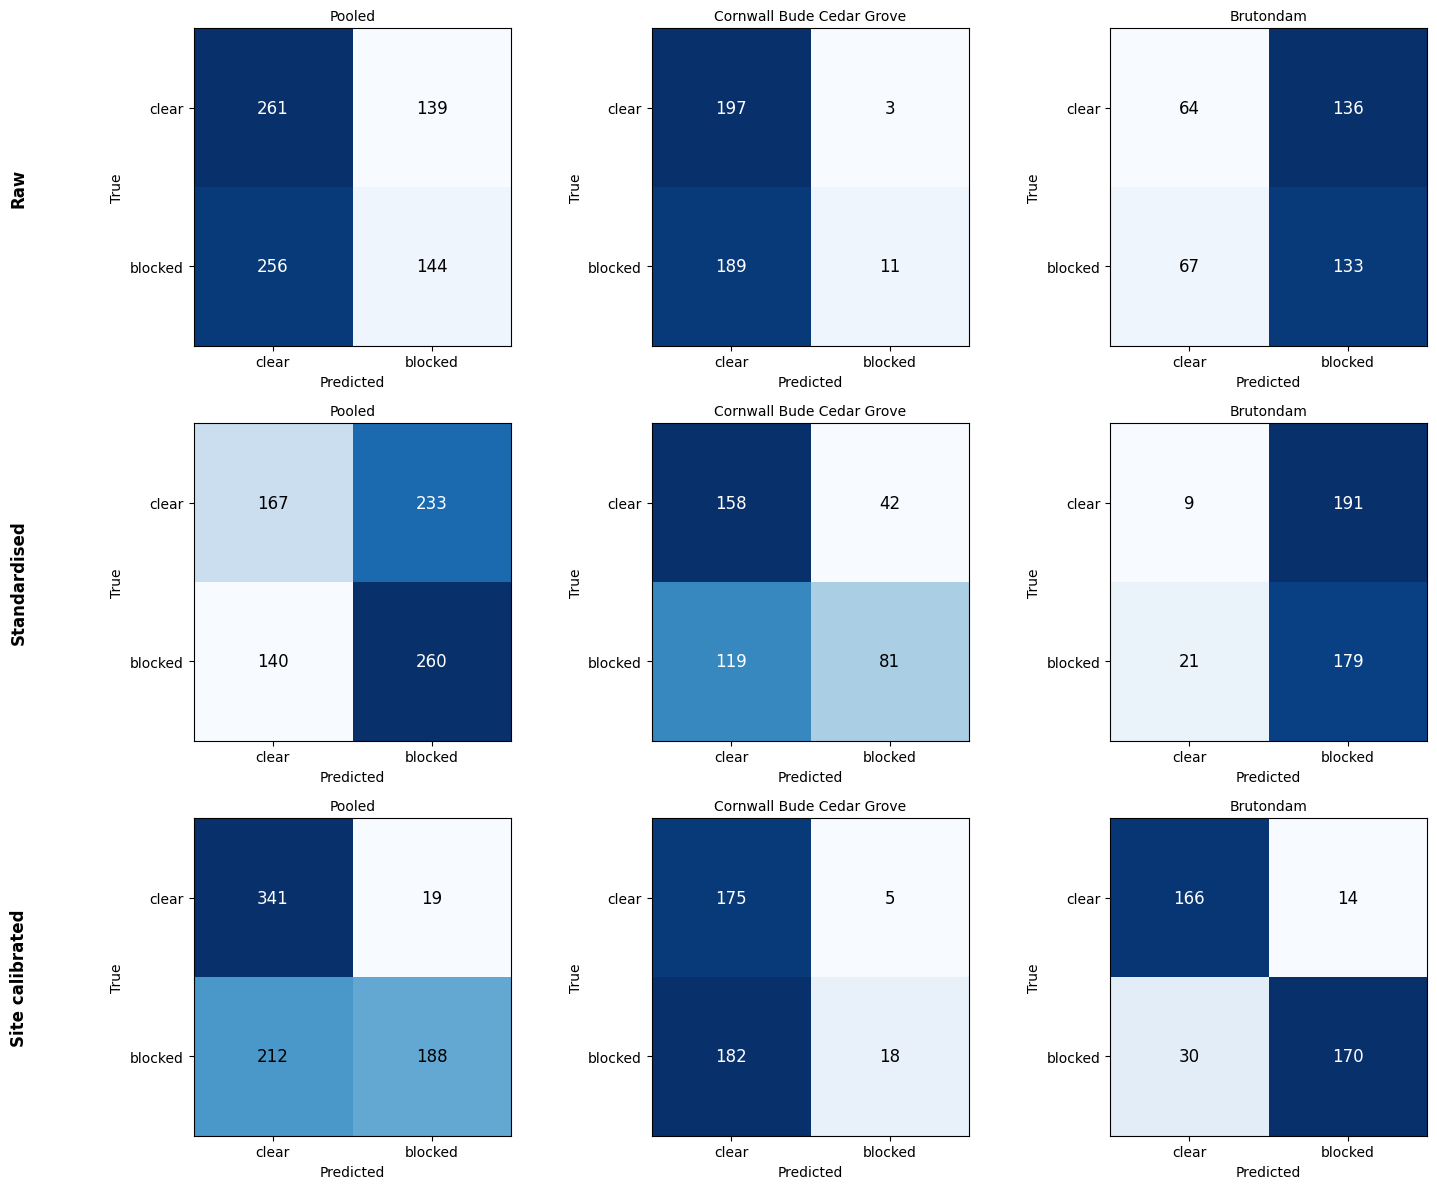

In [ ]:
# Cell 22: Final held-out confusion matrices
# Native OCSVM predictions

DISPLAY_NAMES = {
    "Cornwall_BudeCedarGrove": "Cornwall Bude Cedar Grove",
    "sites_brutondam_cam1": "Brutondam"
}


def plot_blue_confusion(
    y_true,
    y_pred,
    title,
    ax
):

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    image = ax.imshow(
        matrix,
        cmap="Blues"
    )

    ax.set_title(
        title,
        fontsize=10
    )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(
        ["clear", "blocked"]
    )

    ax.set_yticklabels(
        ["clear", "blocked"]
    )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")


    for row in range(2):

        for column in range(2):

            rgba = image.cmap(
                image.norm(
                    matrix[row, column]
                )
            )

            luminance = (
                0.299 * rgba[0]
                + 0.587 * rgba[1]
                + 0.114 * rgba[2]
            )

            text_color = (
                "white"
                if luminance < 0.5
                else "black"
            )

            ax.text(
                column,
                row,
                str(
                    matrix[row, column]
                ),
                ha="center",
                va="center",
                color=text_color,
                fontsize=12
            )

# Conditions

conditions_order = [
    "raw",
    "development_standardised",
    "site_calibrated"
]

row_names = [
    "Raw",
    "Standardised",
    "Site calibrated"
]

# Figure

fig, axes = plt.subplots(
    3,
    3,
    figsize=(15, 12)
)


for row, condition in enumerate(
    conditions_order
):

    condition_df = final_predictions[
        final_predictions["condition"]
        == condition
    ].copy()


    # For calibrated condition, use one repeat for display
    display_seed = condition_df[
        "calibration_seed"
    ].min()

    display_df = condition_df[
        condition_df[
            "calibration_seed"
        ] == display_seed
    ]


    # Pooled
    plot_blue_confusion(
        display_df[
            "true_label"
        ],
        display_df[
            "prediction"
        ],
        "Pooled",
        axes[row, 0]
    )


    # Per-site
    for column, site in enumerate(
        TEST_SITES,
        start=1
    ):

        site_df = display_df[
            display_df[
                "site"
            ] == site
        ]

        plot_blue_confusion(
            site_df[
                "true_label"
            ],
            site_df[
                "prediction"
            ],
            DISPLAY_NAMES.get(
                site,
                site
            ),
            axes[
                row,
                column
            ]
        )


    # Row labels
    axes[row, 0].text(
        -0.55,
        0.5,
        row_names[row],
        transform=axes[
            row,
            0
        ].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )


plt.tight_layout()

plt.savefig(
    f"{OUTPUT_FOLDER}/"
    "final_clear_only_ocsVM_confusion_matrices.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Cell 23: Final reporting table for clear-only OCSVM results
# Mean ± SD is reported for site-calibrated results across 10 repeats.
# Raw and standardised results are deterministic single runs.

def format_metric(mean_value, std_value):

    if pd.isna(std_value):
        return f"{mean_value:.3f}"

    return (
        f"{mean_value:.3f} "
        f"± {std_value:.3f}"
    )


# Build reporting rows


report_rows = []


DISPLAY_CONDITIONS = {
    "raw": "Raw",
    "development_standardised": "Standardised",
    "site_calibrated": "Site calibrated"
}


DISPLAY_SITES = {
    "Cornwall_BudeCedarGrove":
        "Cornwall Bude Cedar Grove",

    "sites_brutondam_cam1":
        "Brutondam"
}


for condition in CONDITIONS:

    # Pooled


    pooled_row = pooled_summary.loc[
        condition
    ]


    report_rows.append({

        "Condition":
            DISPLAY_CONDITIONS[
                condition
            ],

        "Site":
            "Pooled",

        "AUC":
            format_metric(
                pooled_row[
                    ("auc", "mean")
                ],
                pooled_row[
                    ("auc", "std")
                ]
            ),

        "Accuracy":
            format_metric(
                pooled_row[
                    ("accuracy", "mean")
                ],
                pooled_row[
                    ("accuracy", "std")
                ]
            ),

        "Precision":
            format_metric(
                pooled_row[
                    ("precision", "mean")
                ],
                pooled_row[
                    ("precision", "std")
                ]
            ),

        "Recall":
            format_metric(
                pooled_row[
                    ("recall", "mean")
                ],
                pooled_row[
                    ("recall", "std")
                ]
            ),

        "F1":
            format_metric(
                pooled_row[
                    ("f1", "mean")
                ],
                pooled_row[
                    ("f1", "std")
                ]
            )
    })


    # Individual test sites

    for site in TEST_SITES:

        site_row = per_site_summary.loc[
            (
                condition,
                site
            )
        ]


        report_rows.append({

            "Condition":
                DISPLAY_CONDITIONS[
                    condition
                ],

            "Site":
                DISPLAY_SITES.get(
                    site,
                    site
                ),

            "AUC":
                format_metric(
                    site_row[
                        ("auc", "mean")
                    ],
                    site_row[
                        ("auc", "std")
                    ]
                ),

            "Accuracy":
                format_metric(
                    site_row[
                        ("accuracy", "mean")
                    ],
                    site_row[
                        ("accuracy", "std")
                    ]
                ),

            "Precision":
                format_metric(
                    site_row[
                        ("precision", "mean")
                    ],
                    site_row[
                        ("precision", "std")
                    ]
                ),

            "Recall":
                format_metric(
                    site_row[
                        ("recall", "mean")
                    ],
                    site_row[
                        ("recall", "std")
                    ]
                ),

            "F1":
                format_metric(
                    site_row[
                        ("f1", "mean")
                    ],
                    site_row[
                        ("f1", "std")
                    ]
                )
        })


# Final table

final_reporting_table = pd.DataFrame(
    report_rows
)


display(
    final_reporting_table
)


# Save

save_output(
    final_reporting_table,
    "final_clear_only_ocsVM_reporting_table",
    index=False
)

,Condition,Site,AUC,Accuracy,Precision,Recall,F1
0,Raw,Pooled,0.559,0.506,0.509,0.360,0.422
1,Raw,Cornwall Bude Cedar Grove,0.646,0.520,0.786,0.055,0.103
2,Raw,Brutondam,0.547,0.492,0.494,0.665,0.567
3,Standardised,Pooled,0.536,0.534,0.527,0.650,0.582
4,Standardised,Cornwall Bude Cedar Grove,0.632,0.598,0.659,0.405,0.502
5,Standardised,Brutondam,0.487,0.470,0.484,0.895,0.628
6,Site calibrated,Pooled,0.804 ± 0.012,0.705 ± 0.004,0.921 ± 0.016,0.481 ± 0.010,0.632 ± 0.007
7,Site calibrated,Cornwall Bude Cedar Grove,0.734 ± 0.013,0.514 ± 0.004,0.856 ± 0.043,0.093 ± 0.005,0.169 ± 0.009
8,Site calibrated,Brutondam,0.963 ± 0.003,0.896 ± 0.006,0.929 ± 0.016,0.869 ± 0.021,0.897 ± 0.007


Saved: final_clear_only_ocsVM_reporting_table.csv


## 10. ROC curves

ROC curves compare the ranking performance of the three feature conditions across decision thresholds. The held-out AUC values provide the principal threshold-independent comparison.


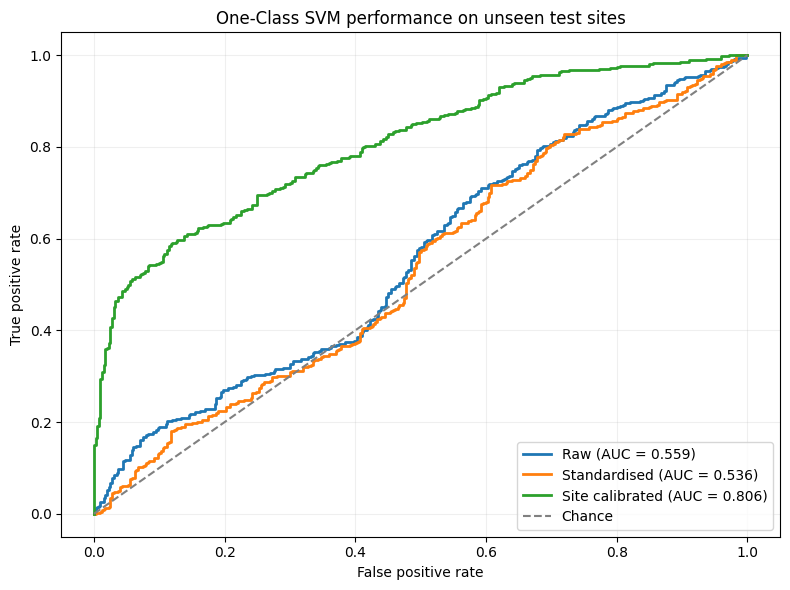

In [ ]:
# Cell 24: Final held-out ROC curves
# Site-calibrated anomaly scores are averaged across the 10 repeats.

from sklearn.metrics import roc_curve, roc_auc_score


# Average repeated scores at image level

roc_predictions = (
    final_predictions
    .groupby(
        [
            "condition",
            "site",
            "metadata_index",
            "true_label"
        ],
        as_index=False
    )
    .agg(
        anomaly_score=(
            "anomaly_score",
            "mean"
        )
    )
)


# Plot

plt.figure(
    figsize=(8, 6)
)


ROC_LABELS = {
    "raw": "Raw",
    "development_standardised": "Standardised",
    "site_calibrated": "Site calibrated"
}


for condition in CONDITIONS:

    condition_df = roc_predictions[
        roc_predictions[
            "condition"
        ] == condition
    ]


    y_true = condition_df[
        "true_label"
    ].to_numpy()

    scores = condition_df[
        "anomaly_score"
    ].to_numpy()


    auc = roc_auc_score(
        y_true,
        scores
    )


    fpr, tpr, _ = roc_curve(
        y_true,
        scores
    )


    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{ROC_LABELS[condition]} "
            f"(AUC = {auc:.3f})"
        )
    )


# Chance line


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Chance"
)


# Formatting

plt.xlabel(
    "False positive rate"
)

plt.ylabel(
    "True positive rate"
)

plt.title(
    "One-Class SVM performance on unseen test sites"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()


# Save

plt.savefig(
    f"{OUTPUT_FOLDER}/"
    "final_clear_only_ocsVM_ROC_curves.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 11. Aggregated site-calibrated result

For the final site-calibrated analysis, repeated anomaly scores are aggregated at image level before the native OCSVM decision boundary is applied. This produces the final pooled and site-specific result reported by the notebook.


In [ ]:
# Final aggregated OCSVM evaluation
# Average site-calibrated anomaly scores across calibration repeats.
# The native OCSVM decision boundary is retained:
# anomaly_score > 0 -> blocked/anomaly
# anomaly_score <= 0 -> clear

site_calibrated_predictions = (
    final_predictions[
        final_predictions["condition"] == "site_calibrated"
    ]
    .copy()
)


# ------------------------------------------------------------
# Average repeated anomaly scores for each image
# ------------------------------------------------------------

final_aggregated_predictions = (
    site_calibrated_predictions
    .groupby(
        [
            "site",
            "metadata_index",
            "true_label"
        ],
        as_index=False
    )
    .agg(
        anomaly_score=(
            "anomaly_score",
            "mean"
        ),
        n_repeats=(
            "anomaly_score",
            "count"
        )
    )
)


# ------------------------------------------------------------
# Apply native OCSVM decision boundary
#
# Original:
# decision_function < 0 -> anomaly
#
# Since:
# anomaly_score = -decision_function
#
# Therefore:
# anomaly_score > 0 -> blocked
# ------------------------------------------------------------

final_aggregated_predictions[
    "prediction"
] = (
    final_aggregated_predictions[
        "anomaly_score"
    ] > 0
).astype(int)


# ------------------------------------------------------------
# Metric helper
# ------------------------------------------------------------

def compute_final_metrics(df):

    y_true = df[
        "true_label"
    ].to_numpy()

    scores = df[
        "anomaly_score"
    ].to_numpy()

    predictions = df[
        "prediction"
    ].to_numpy()


    return {
        "auc":
            roc_auc_score(
                y_true,
                scores
            ),

        "accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "f1":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "n_images":
            len(df)
    }


# ------------------------------------------------------------
# Pooled result
# ------------------------------------------------------------

pooled_metrics = compute_final_metrics(
    final_aggregated_predictions
)


# ------------------------------------------------------------
# Per-site results
# ------------------------------------------------------------

result_rows = [
    {
        "site": "Pooled",
        **pooled_metrics
    }
]


for site in TEST_SITES:

    site_df = (
        final_aggregated_predictions[
            final_aggregated_predictions[
                "site"
            ] == site
        ]
    )

    result_rows.append(
        {
            "site":
                DISPLAY_NAMES.get(
                    site,
                    site
                ),

            **compute_final_metrics(
                site_df
            )
        }
    )


final_ocsVM_metrics = pd.DataFrame(
    result_rows
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print(
    "Final aggregated site-calibrated OCSVM performance"
)

display(
    final_ocsVM_metrics.round(4)
)


print(
    "\nNumber of repeat scores available per image:"
)

display(
    final_aggregated_predictions[
        "n_repeats"
    ].value_counts().sort_index()
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

save_output(
    final_aggregated_predictions,
    "final_clear_only_ocsVM_aggregated_predictions",
    index=False
)

save_output(
    final_ocsVM_metrics,
    "final_clear_only_ocsVM_aggregated_metrics",
    index=False
)

Final aggregated site-calibrated OCSVM performance


,site,auc,accuracy,precision,recall,f1,n_images
0,Pooled,0.8064,0.7200,0.9190,0.4825,0.6328,800
1,Cornwall Bude Cedar Grove,0.7396,0.5375,0.8261,0.0950,0.1704,400
2,Brutondam,0.9649,0.9025,0.9305,0.8700,0.8992,400



Number of repeat scores available per image:


,count
n_repeats,
6,3
7,22
8,86
9,150
10,539


Saved: final_clear_only_ocsVM_aggregated_predictions.csv
Saved: final_clear_only_ocsVM_aggregated_metrics.csv


### ROC curve interpretation

The ROC curves demonstrate that the ability of the One-Class SVM to distinguish clear and blocked images on unseen sites depends on how site variation is handled. Using the raw DINOv3 embeddings resulted in an AUC of 0.559, while development standardisation produced an AUC of 0.536. Both curves remain relatively close to the chance diagonal, indicating limited discrimination between clear and blocked images across the unseen sites.

Site calibration substantially improved discrimination, producing an AUC of 0.806. The corresponding ROC curve remains above the chance line across most classification thresholds, indicating that blocked images generally received higher anomaly scores than clear images after site-specific variation was reduced.

The ROC result should be considered alongside the native One-Class SVM classifications. Although the site-calibrated anomaly scores achieved good overall discrimination, the native decision boundary produced a pooled recall of 0.481. This indicates that the learned anomaly score contains useful information for identifying blockage, but the clear-only decision boundary remains conservative and does not identify all blocked images.

Overall, the results suggest that frozen DINOv3 embeddings can support clear-only anomaly detection, but cross-site variation substantially affects performance. Calibration using clear reference images improves transfer to unseen sites, although blockage detection remains dependent on the characteristics of the individual camera site.